# Exact inference on gapped data: time domain vs full windowed covariance

End-to-end example of joint **signal + noise** parameter estimation on gapped
LISA-like data with the two *exact* likelihood tiers of `gaplike`:

* `TimeDomainExact` — the likelihood of the observed samples themselves
  (missing samples marginalized = rows/columns deleted); **no window appears
  anywhere**;
* `FullCovariance` — the windowed, band-restricted frequency-domain data with
  its **dense** covariance (all leakage correlations retained).

The paper's message, in miniature: the two posteriors should lie on top of
each other, centred on the truth — even under a drastic periodic gap comb
(20% of all samples removed).

Everything is self-contained: two-channel TM+OMS noise, a toy chirp signal,
4 inferred parameters (2 signal + 2 noise). **No lisabeta required.**
Runtime: ~5–10 minutes (two short MCMC runs plus two one-off O(m³)/O(N_b³)
factorizations).

```
uv pip install -e "..[pe]"     # gaplike + emcee + corner + matplotlib
```

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import emcee, corner

import gaplike as gl

np.random.seed(0)
rng = np.random.default_rng(42)

# ---- configuration: 12 h of TDI2 A/E at 15 s cadence ----------------------
n, dt = 2880, 15.0
f_lo, f_hi = 1e-4, 3.1e-2                    # analysis band [Hz]
t = np.arange(n) * dt

# ---- gaps: the paper's scenario-C comb — 150 s removed every 750 s --------
mask = gl.gaps.periodic_mask(n, 10, 50)
gate = gl.gaps.gate_from_mask(mask, dt, taper_s=0.0)      # rectangular gate
w_eff = gl.gaps.effective_window(gate, gl.gaps.segment_window(n, 0.05))
obs = np.flatnonzero(np.asarray(mask) > 0)
print(f"N = {n}, observed m = {obs.size}, duty cycle = {obs.size/n:.0%}")

N = 2880, observed m = 2300, duty cycle = 80%


In [2]:
# ---- noise: two components (TM + OMS), truth at lam = (0, 0) ---------------
comps = list(gl.psd.lisa_tdi2_ae().values())              # [S_tm(f), S_oms(f)]
S_tot = gl.psd.one_sided_grid(lambda f: comps[0](f) + comps[1](f), n, dt)
noise = gl.simulate.noise_td(S_tot, dt, rng, nch=2)       # (2, n)

# ---- toy signal: Gaussian-envelope chirp, same template in both channels ---
T0, TAU = 6 * 3600.0, 1.5 * 3600.0           # centre, envelope width [s]
FDOT, PHI0 = 1e-7, 0.6                        # chirp rate [Hz/s], phase

def template(theta):
    # theta = (log10 A, f0 [mHz]) -> (2, n) time-domain template
    log10A, f0_mHz = theta
    x = t - T0
    phase = 2 * np.pi * (1e-3 * f0_mHz * x + 0.5 * FDOT * x**2) + PHI0
    h = 10.0**log10A * np.exp(-0.5 * (x / TAU)**2) * np.sin(phase)
    return np.stack([h, h])

theta_true = np.array([0.0, 3.0])            # amplitude fixed below via SNR
lam_true = (0.0, 0.0)

# scale the amplitude so the TD-exact SNR is ~60
L_td_tmp = gl.TimeDomainExact(mask, comps, dt)
h1 = template(theta_true)[:, obs]
z = L_td_tmp.T @ h1.T
snr1 = np.sqrt(np.sum(z**2 / L_td_tmp.variances(lam_true)[:, None]))
A = 60.0 / snr1
theta_true[0] = np.log10(A)
data = noise + template(theta_true)
print(f"SNR (exact, gapped) = 60 by construction; log10 A_true = {theta_true[0]:.3f}")

SNR (exact, gapped) = 60 by construction; log10 A_true = -21.440


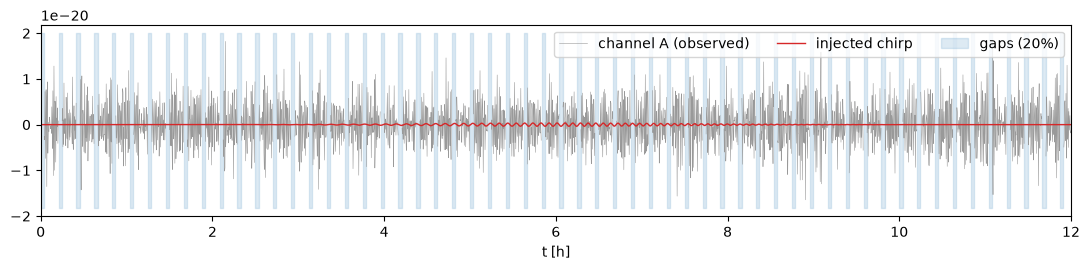

In [3]:
fig, ax = plt.subplots(figsize=(11, 2.8))
x_show = np.where(np.asarray(mask) > 0, data[0], np.nan)   # hide gap samples
ax.plot(t / 3600, x_show, lw=0.4, color="0.6", label="channel A (observed)")
ax.plot(t / 3600, template(theta_true)[0], lw=1.0, color="tab:red", label="injected chirp")
ax.fill_between(t / 3600, *ax.get_ylim(), where=np.asarray(mask) <= 0,
                color="tab:blue", alpha=0.15, label="gaps (20%)")
ax.set_xlabel("t [h]"); ax.set_xlim(0, 12); ax.legend(loc="upper right", ncol=3)
plt.tight_layout()

## The two exact tiers

`TimeDomainExact` diagonalizes the two restricted component covariances once
(*simultaneous diagonalization*, O(m³)); every likelihood evaluation is then
O(m) with a closed-form determinant. `FullCovariance` does the same in the
band-restricted frequency domain, where the gaps' leakage appears as bin–bin
correlations. Both are exact descriptions of the same data — they must agree.

In [4]:
L_td = L_td_tmp                    # factorized above, for the SNR normalization
print(f"TimeDomainExact ready (m = {L_td.m})")

t0 = time.time()
L_full = gl.FullCovariance.from_window(w_eff, comps, dt, f_lo, f_hi)
print(f"FullCovariance ready  ({time.time()-t0:.1f} s, rank = {L_full.rank} "
      f"of {L_full.n_band} band bins)")

# residual pipelines: full-grid time series -> each tier's data vector
resid_td = lambda th: (data - template(th))[:, obs]
resid_fd = lambda th: L_full.transform(data - template(th))

for name, L, r in [("TD exact ", L_td, resid_td(theta_true)),
                   ("FD full  ", L_full, resid_fd(theta_true))]:
    d0 = L.loglike(r, lam_true) - L.loglike(r, (0.1, 0.0))
    print(f"{name}: logL(truth) - logL(lam_tm=0.1) = {d0:8.2f}")

TimeDomainExact ready (m = 2300)
FullCovariance ready  (3.8 s, rank = 1331 of 1335 band bins)
TD exact : logL(truth) - logL(lam_tm=0.1) =     2.17
FD full  : logL(truth) - logL(lam_tm=0.1) =     2.54


In [5]:
# ---- joint 4-parameter PE: theta = (log10 A, f0 [mHz], lam_tm, lam_oms) ----
lo = np.array([theta_true[0] - 0.4, theta_true[1] - 0.02, -1.0, -1.0])
hi = np.array([theta_true[0] + 0.4, theta_true[1] + 0.02,  1.0,  1.0])
x_true = np.array([*theta_true, *lam_true])
labels = [r"$\log_{10}A$", r"$f_0$ [mHz]", r"$\lambda_{\rm tm}$", r"$\lambda_{\rm oms}$"]

def make_logpost(loglike, resid):
    def logpost(x):
        if np.any(x < lo) or np.any(x > hi):
            return -np.inf
        return loglike(resid(x[:2]), (x[2], x[3]))
    return logpost

def run(logpost, nw=24, nstep=600, seed=1):
    p0 = x_true + 1e-4 * np.random.default_rng(seed).standard_normal((nw, 4))
    sam = emcee.EnsembleSampler(nw, 4, logpost)
    t0 = time.time()
    sam.run_mcmc(p0, nstep, progress=False)
    ch = sam.get_chain(discard=200, thin=4, flat=True)
    print(f"  {nw}x{nstep} in {time.time()-t0:.0f} s, "
          f"acceptance {np.mean(sam.acceptance_fraction):.2f}, "
          f"{ch.shape[0]} samples")
    return ch

print("sampling with TimeDomainExact ...")
ch_td = run(make_logpost(L_td.loglike, resid_td))
print("sampling with FullCovariance ...")
ch_fd = run(make_logpost(L_full.loglike, resid_fd))

sampling with TimeDomainExact ...
  24x600 in 16 s, acceptance 0.60, 2400 samples
sampling with FullCovariance ...
  24x600 in 14 s, acceptance 0.60, 2400 samples


posterior comparison (TD vs FD-full), per parameter:
  $\log_{10}A$           mean shift  0.46 sigma   width ratio  0.96   truth at  1.41 sigma (TD)
  $f_0$ [mHz]            mean shift  0.34 sigma   width ratio  0.92   truth at  0.61 sigma (TD)
  $\lambda_{\rm tm}$     mean shift  0.68 sigma   width ratio  1.23   truth at  0.17 sigma (TD)
  $\lambda_{\rm oms}$    mean shift  0.16 sigma   width ratio  0.93   truth at  0.44 sigma (TD)


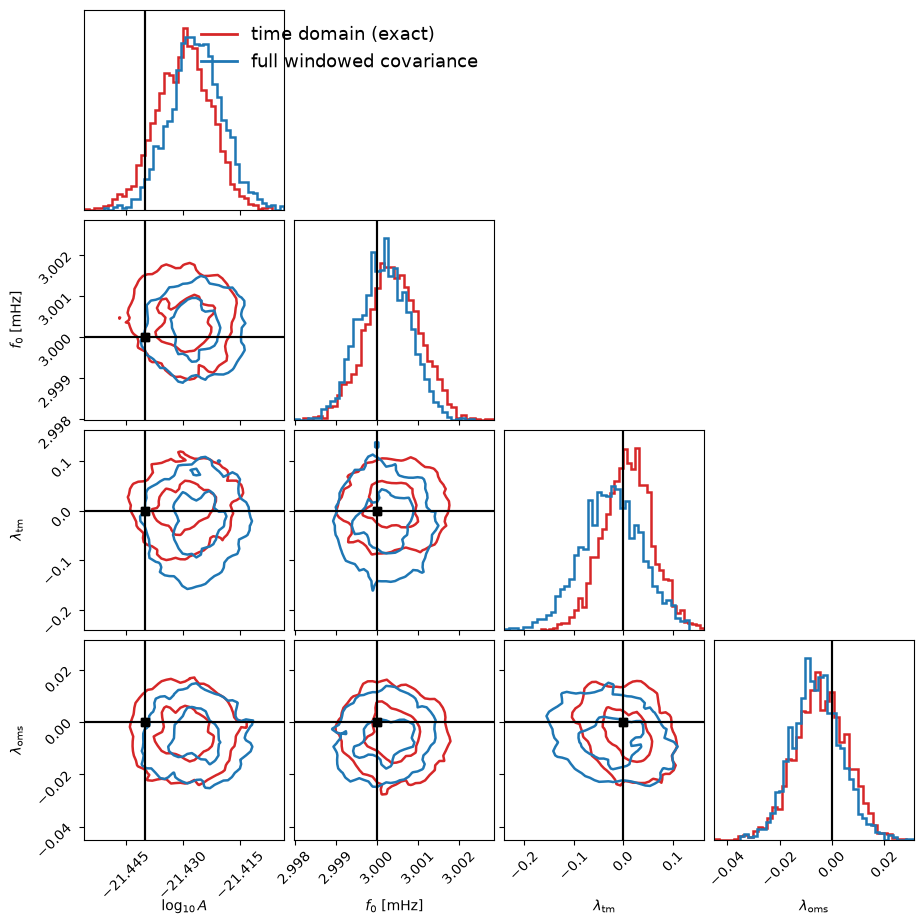

In [6]:
def kw(c):                    # corner mutates kwargs dicts in place: fresh ones per call
    return dict(labels=labels, truths=x_true, truth_color="k",
                plot_datapoints=False, plot_density=False, levels=(0.393, 0.865),
                smooth=0.9, bins=40, color=c,
                hist_kwargs={"density": True, "lw": 1.8, "color": c},
                contour_kwargs={"linewidths": 1.8, "colors": c})

fig = corner.corner(ch_td, **kw("tab:red"))
fig = corner.corner(ch_fd, fig=fig, **kw("tab:blue"))
fig.axes[1].legend(handles=[plt.Line2D([], [], color=c, lw=2, label=l)
                            for c, l in [("tab:red", "time domain (exact)"),
                                         ("tab:blue", "full windowed covariance")]],
                   loc="upper right", frameon=False, fontsize=13)

print("posterior comparison (TD vs FD-full), per parameter:")
for i, lab in enumerate(labels):
    m1, s1 = ch_td[:, i].mean(), ch_td[:, i].std()
    m2, s2 = ch_fd[:, i].mean(), ch_fd[:, i].std()
    print(f"  {lab:22s} mean shift {abs(m1-m2)/s1:5.2f} sigma"
          f"   width ratio {s2/s1:5.2f}"
          f"   truth at {abs(m1-x_true[i])/s1:5.2f} sigma (TD)")

## Scaling up: the same likelihood, matrix-free

Both tiers above pay a one-off dense factorization — fine at m ≈ 2300,
impossible at m ≈ 10⁵. `gaplike.cg` evaluates the *same* time-domain
quadratic form by preconditioned conjugate gradients: the covariance is never
formed, one solve is a few hundred FFT pairs, and nothing assumes the
two-component structure (see `paper/fig_cg_scaling.py` for the dense-vs-CG
scaling benchmark).

In [7]:
rcg = gl.RestrictedCG(mask, comps, dt, rtol=1e-10)
r = resid_td(theta_true)
quad_cg, iters = rcg.quad_form(lam_true, r)
z = L_td.T @ r.T
quad_pencil = float(np.sum(z**2 / L_td.variances(lam_true)[:, None]))
print(f"n^T Sigma_OO^-1 n   pencil {quad_pencil:.10e}")
print(f"                    CG     {quad_cg:.10e}   ({iters} iterations)")
print(f"relative difference {abs(quad_cg-quad_pencil)/quad_pencil:.2e}")

n^T Sigma_OO^-1 n   pencil 4.5691816911e+03
                    CG     4.5691816911e+03   ([436, 438] iterations)
relative difference 6.37e-13


---
**Where to go next**: `paper/README.md` reproduces every figure of the paper
(three gap scenarios, four likelihood tiers, the Υ/Ξ calibration diagnostics,
and the CG-vs-dense scaling benchmark); `gaplike.waveform.lisabeta_mbhb_ae`
swaps the toy chirp for the paper's IMRPhenomHM MBHB.